In [1]:
import pandas as pd
data=pd.read_csv('AB_NYC_2019.csv')

## Datanın ilkin baxışı

İlk olaraq dataset-in ölçüsünə baxıram — neçə sətir (elan) və neçə sütun (xüsusiyyət) olduğunu görmək üçün.

In [2]:
data.shape  # # sətir/sütun sayı

(48895, 16)

Dataset **48,895 sətir** və **16 sütundan** ibarətdir. Bu, kifayət qədər böyük bir dataset olduğu üçün, boş dəyərlərin kiçik faizi (məs. 1-2%) analiz nəticəsinə ciddi təsir etməyəcək.

### Sütunların tipləri

Hər sütunun məlumat tipini yoxlayıram ki, hansı sütunun rəqəm, hansının mətn olduğunu görüm — bu, sonrakı təmizləmə addımları üçün vacibdir.

In [3]:
data.dtypes  #sutunlarin tipleri

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Əksər sütunlar düzgün tipdədir. Amma `last_review` sütunu mətn (`object`) kimi görünür, halbuki bu bir tarixdir sonrakı addımlarda `datetime` formatına çevriləcək.

In [4]:
data.head(10) #datanin ilk 10setrine baxaq 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


### Boş dəyərlərin yoxlanılması

Hər sütunda neçə boş (NaN) dəyər olduğunu yoxlayıram.

In [5]:
data.isnull().sum()  #her sutunda ne qeder NaN deyer olduguna baxaq

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

`name` (16) və `host_name` (21) sütunlarında az sayda boş dəyər var — əhəmiyyətsiz səviyyədədir.

`last_review` və `reviews_per_month` sütunlarında isə **hər ikisində eyni sayda (10,052) boş dəyər** var. Bu təsadüfi deyil — bu, **sistemli boşluqdur (MNAR)**: elana heç review yazılmayıbsa, "son review tarixi" və "aylıq review sayı" da təbii olaraq mövcud olmur. Bunu checkpoint 2-də median əvəzinə məntiqi dəyərlərlə (məs. 0) dolduracağam.

### Dublikat sətirlərin yoxlanılması

Bütün sütunlar üzrə tam təkrarlanan sətir olub-olmadığını yoxlayıram.

In [6]:
data.duplicated().sum()

0

Dataset-də **0 dublikat sətir** tapıldı. Deməli, məlumat daxiletmə zamanı təkrarlanan qeyd problemi yoxdur.


### CHECKPOINT 2

## Boş dəyərlərin idarə olunması

### `name` və `host_name` sütunları

Bu iki sütunda az sayda boş dəyər var (16 və 21). Hər ikisi mətn (kateqorik) sütun olduğu üçün median/mod kimi statistik üsullar uyğun deyil. Bunun əvəzinə "Unknown" dəyəri ilə dolduracağam — bu, məlumatın olmadığını aydın göstərir, həm də bu az sayda sətri silmək lazımsızdır, çünki digər sütunlarda dəyərli məlumat var.

In [7]:
data['name']=data['name'].fillna('Unknown')
data['host_name']=data['host_name'].fillna('Unknown')
print(data['name'].isnull().sum())
data['host_name'].isnull().sum()

0


0

`name` və `host_name` sütunlarındakı boş dəyərlər "Unknown" ilə əvəz olundu. Yoxlama nəticəsində hər iki sütunda 0 boş dəyər qaldığı təsdiqləndi.

### 
`reviews_per_month` sütunu

Bu sütunda 10,052 boş dəyər var. Yoxladıqda gördüm ki, bu sətirlərin hamısında `number_of_reviews = 0`-dır — yəni elana heç review yazılmayıb. Bu, təsadüfi boşluq deyil, sistemli boşluqdur (MNAR): review yoxdursa, "aylıq review sayı" da təbii olaraq 0 olmalıdır, median ilə doldurmaq səhv olardı çünki uydurma məlumat yaradardı. Ona görə bu sütunu 0 ilə dolduracağam.

In [8]:
data['reviews_per_month']=data['reviews_per_month'].fillna(0)
data['reviews_per_month'].isnull().sum()

0

### `last_review` sütunu

Bu sütun tarixdir, amma mətn (`object`) tipində saxlanılıb. Onu `datetime` formatına çevirirəm ki, gələcəkdə tarix üzrə əməliyyatlar (məs. neçə vaxtdır review yazılmadığını hesablamaq) mümkün olsun. Boş dəyərləri (review yazılmayan elanlar) doldurmuram — çünki bunlara uydurma tarix vermək yanlış olardı, "tarix yoxdur" mənası itərdi.

In [9]:
data['last_review'] = pd.to_datetime(data['last_review'])
data.dtypes['last_review']

dtype('<M8[ns]')

`last_review` sütunu uğurla `datetime` formatına çevrildi. Boş dəyərlər (10,052 ədəd) qəsdən saxlanıldı, çünki bunlar review yazılmayan elanlara aiddir və bu, özü bir məlumatdır 

### `has_review` sütununun yaradılması

`last_review` və `reviews_per_month` sütunlarındakı boşluğun səbəbini aydın göstərmək üçün yeni bir sütun yaradıram: `has_review`. Bu, elana heç olmasa bir review yazılıb-yazılmadığını (True/False) göstərir və gələcəkdə (vizuallaşdırma və ya ML mərhələsində) faydalı olacaq.

In [10]:
data['has_review'] = data['number_of_reviews'] > 0
data['has_review']

0         True
1         True
2        False
3         True
4         True
         ...  
48890    False
48891    False
48892    False
48893    False
48894    False
Name: has_review, Length: 48895, dtype: bool

`has_review` sütunu uğurla yaradıldı. Bu sütun review yazılmayan elanları aydın işarələyir və `last_review`/`reviews_per_month` sütunlarındakı boşluğun səbəbini izah edir.

In [11]:
data.isnull().sum()  #umumi yoxlama

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
has_review                            0
dtype: int64

### CHECKPOINT 3

## Outlier-lərin aşkarlanması

Rəqəmsal sütunlarda (price, minimum_nights, number_of_reviews) qeyri-adi dəyərlərin olub-olmadığını yoxlamaq üçün əvvəlcə statistik xülasəyə baxıram.

In [12]:
data[['price','minimum_nights','number_of_reviews']].describe()

,price,minimum_nights,number_of_reviews
count,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466
std,240.154170,20.510550,44.550582
min,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000
50%,106.000000,3.000000,5.000000
75%,175.000000,5.000000,24.000000
max,10000.000000,1250.000000,629.000000


### `minimum_nights` outlier-lərinin işlənməsi

`describe()` nəticəsində gördüm ki, `minimum_nights` sütununda median 3 gecədir, amma maksimum 1250 gecədir (3.4 il). Bu, realist deyil — heç bir normal host bu qədər uzun minimum müddət qoymaz. Bu, çox güman məlumat daxiletmə səhvidir, real dəyər deyil. Ona görə bu outlier-ləri silməyi qərara aldım (1 ildən, yəni 365 gündən çox olan dəyərləri).

In [13]:
data=data[data['minimum_nights']<=365]
#`minimum_nights` sütunundakı məntiqsiz dəyərlər (365 gündən çox) silindi. Bu, datasetin ümumi ölçüsünə əhəmiyyətli təsir etmədi, çünki bu cür dəyərlər çox az sayda idi.

IQR metodunu tətbiq edərək price sütununda statistik outlier həddini hesablayıram.

In [14]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers_count = data[data['price'] > upper_bound].shape[0]
print(f"IQR-ə görə üst hədd: {upper_bound}")
print(f"Bu həddən yuxarı olan sətir sayı: {outliers_count}")

IQR-ə görə üst hədd: 334.0
Bu həddən yuxarı olan sətir sayı: 2971


IQR metoduna görə üst hədd 334-dür və bu həddən yuxarı 2,971 sətir (~6%) var. Bu, kifayət qədər böyük bir faizdir və NYC kimi bahalı bir şəhərdə lüks mülklərin mövcudluğunu əks etdirir. Bu sətirləri silmək əhəmiyyətli məlumat itkisinə səbəb olardı, ona görə IQR-in "outlier" kimi qeyd etdiyi bu dəyərləri silmədən saxlamağı qərara aldım — çünki onlar statistik anomaliya deyil, bazarın təbii bir seqmentidir.

In [15]:
data=data[data['price'] > 0]

In [16]:
data.shape  #silinmeden sonra ne qeder setir,sutun qaldigina baxaq

(48870, 17)

### CHECKPOINT 4

### Feature 1: `price_category`

`price` sütununu 3 mənalı kateqoriyaya bölürəm: Budget, Mid-range, Luxury. Hədləri özbaşına seçmədim — checkpoint 1-də `describe()` nəticəsindəki 25% (69) və 75% (175) dəyərlərinə əsaslandım. Bu, sonrakı analizdə (məs. "hansı rayonda ucuz elanlar cəmləşib") faydalı olacaq.

In [17]:
def price_category(price):
    if price<=69:
        return 'Budget'
    elif price<=175:
        return 'Mid-range'
    else:
        return 'Luxury'
data['price_category']=data['price'].apply(price_category)
data['price_category'].value_counts()

price_category
Mid-range    24340
Budget       12357
Luxury       12173
Name: count, dtype: int64

Nəticə gözlənildiyi kimi çıxdı: Mid-range 24,340 (~50%), Budget 12,357 (~25%), Luxury 12,173 (~25%). Bölgü balanslıdır, çünki hədlər məhz quartile dəyərlərindən götürülüb.

### Feature 2: `popularity_score`

Datasetdə birbaşa "reytinq" və ya "məmnunluq" göstəricisi yoxdur. Bunun əvəzinə, mövcud iki sütunu (number_of_reviews və reviews_per_month) birləşdirərək populyarlığı təxmin edən bir proxy dəyişən yaradıram: review sayı × aylıq review tezliyi. Yüksək dəyər, elanın həm çox, həm də davamlı olaraq rezervasiya olunduğunu göstərir.

In [18]:
data['popularity_score']=data['number_of_reviews']*data['reviews_per_month']
print(data['popularity_score'].describe())
data['popularity_score']

count    48870.000000
mean        67.336742
std        233.770009
min          0.000000
25%          0.050000
50%          2.070000
75%         32.487500
max       9170.820000
Name: popularity_score, dtype: float64


0           1.89
1          17.10
2           0.00
3        1252.80
4           0.90
          ...   
48890       0.00
48891       0.00
48892       0.00
48893       0.00
48894       0.00
Name: popularity_score, Length: 48870, dtype: float64

`popularity_score`-un paylanması price sütununa bənzər forma göstərir: median 2.07-dir, amma mean 67.3-dür — bu fərq bir neçə çox uğurlu elanın (məs. max=9170.8) ortalamanı yuxarı çəkdiyini göstərir. Bu, statistik səhv deyil, sadəcə bəzi elanların digərlərindən əhəmiyyətli dərəcədə populyar olduğunu əks etdirir. Bu sütuna outlier işləməsi tətbiq etmədim, çünki yüksək dəyərlər real uğuru göstərir, silinməli deyil.

### CHECKPOINT 5

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

### Qiymətlərin paylanması

`price` sütununun necə paylandığını vizual olaraq görmək üçün histogram çəkirəm.

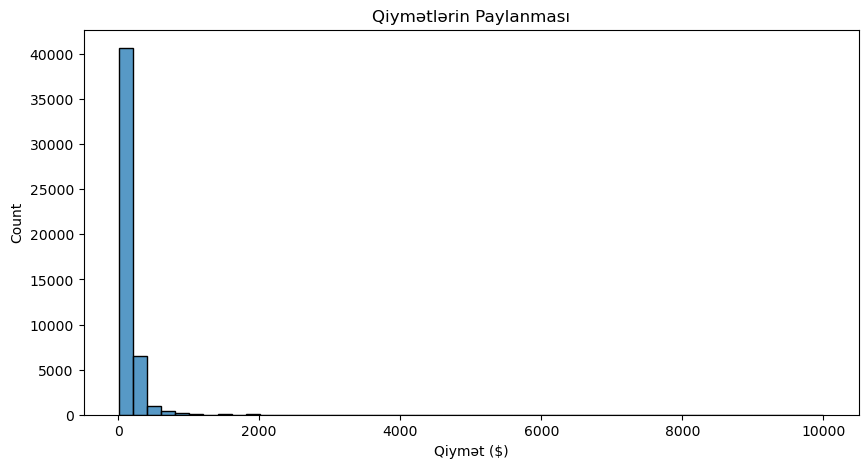

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(data['price'], bins=50)
plt.title('Qiymətlərin Paylanması')
plt.xlabel('Qiymət ($)')
plt.show()

Qrafik göstərir ki, paylanma güclü şəkildə sağa əyilmişdir (right-skewed) — elanların böyük əksəriyyəti 0-500$ aralığında cəmləşib, 2000 dollardan yuxarı isə çox nadirdir. Bu forma, checkpoint 1-də gördüyümüz mean (152.7) və median (106) arasındakı fərqi vizual olaraq təsdiqləyir — az sayda yüksək qiymətli elan ortalamanı yuxarı çəkir.

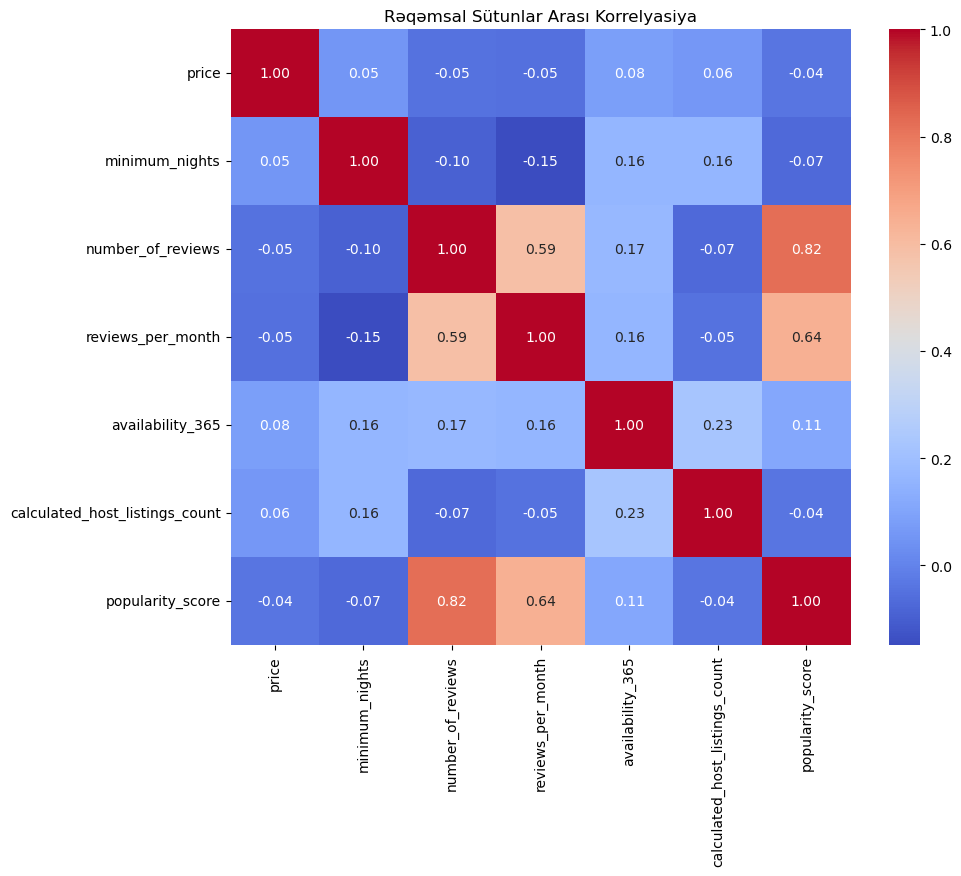

In [21]:
#### Korrelyasiya Heatmap
#Rəqəmsal sütunlar arasındakı əlaqələri görmək üçün korrelyasiya heatmap çəkirəm. Bu, hansı dəyişənlərin bir-biri ilə əlaqəli olduğunu, hansılarının müstəqil olduğunu göstərəcək.
plt.figure(figsize=(10,8))
corr_data = data[['price', 'minimum_nights', 'number_of_reviews', 
                   'reviews_per_month', 'availability_365', 
                   'calculated_host_listings_count', 'popularity_score']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Rəqəmsal Sütunlar Arası Korrelyasiya')
plt.show()

Heatmap-də ən güclü əlaqə number_of_reviews ilə popularity_score arasında (0.82) — bu gözlənilən nəticədir, çünki popularity_score elə number_of_reviews əsasında hesablanıb. reviews_per_month ilə popularity_score arasında da güclü əlaqə var (0.64).

Maraqlı nəticə: price demək olar heç bir sütunla güclü əlaqəli deyil (bütün dəyərlər 0.05-0.08 arasında, sıfıra yaxın). Bu, qiymətin review sayından, minimum gecə tələbindən, yerin əlçatanlığından və host-un mülk sayından demək olar asılı olmadığını göstərir — yəni bu amillər qiymətqoyma ilə deyil, fərqli faktorlarla (məsələn yerləşmə, otaq tipi) müəyyən olunur ola bilər.

### Otaq Tipinə Görə Qiymət Müqayisəsi

room_type kateqoriyasına görə orta qiyməti müqayisə edirəm ki, otaq tipinin qiymətə təsirini görək.

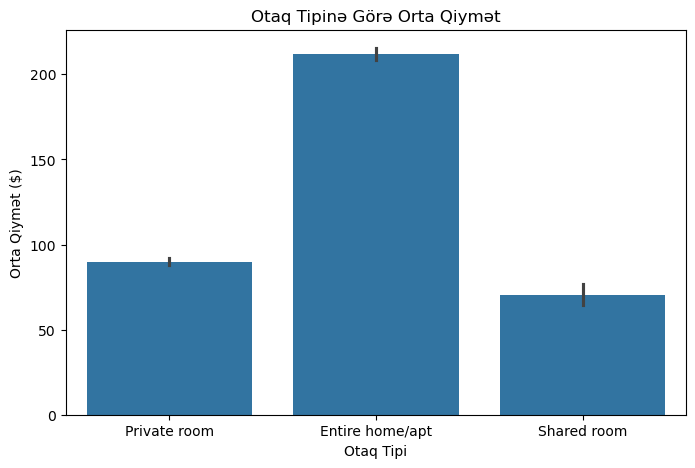

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(data=data, x='room_type', y='price', estimator='mean')
plt.title('Otaq Tipinə Görə Orta Qiymət')
plt.xlabel('Otaq Tipi')
plt.ylabel('Orta Qiymət ($)')
plt.show()

Nəticə gözlənildiyi kimidir: Entire home/apt ən baha (~210 dollar), Private room ortada (~90 dollar), Shared room ən ucuzdur (~70 dollar). Bu, məntiqlidir — qonaq nə qədər çox məkanı tək istifadə edirsə, qiymət bir o qədər yüksəkdir. Maraqlıdır ki, əvvəlki heatmap-də rəqəmsal amillər (review sayı, minimum gecə) price ilə zəif əlaqəli çıxmışdı, amma kateqorik amil (room_type) price ilə aydın, güclü əlaqə göstərir — deməli qiymət daha çox otaq tipi kimi struktur amillərdən asılıdır.